# CSI5388/ELG5271 – Assignment 2 | Part I: Static Model
**DNS Data Exfiltration Detection – Binary Classification**  
University of Ottawa | Winter 2025/2026


## 0. Imports & Configuration

In [3]:
# ── Standard libraries ──────────────────────────────────────────────────
import warnings, hashlib, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: preprocessing ──────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

# ── Scikit-learn: feature selection ──────────────────────────────────────
from sklearn.feature_selection import (
    mutual_info_classif, chi2, SelectKBest, f_classif
)

# ── Scikit-learn: models ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ── Scikit-learn: metrics ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, ConfusionMatrixDisplay
)

# ── Persistence ───────────────────────────────────────────────────────────
import joblib

# ── Aesthetics ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print("All imports successful ✓")


All imports successful ✓


## 1. Data Analysis

### 1.1 Load Dataset

In [6]:
# Load the static DNS dataset
df = pd.read_csv('Static_dataset.csv')

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print()
df.head()


Dataset shape : (268074, 16)
Columns       : ['timestamp', 'FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'longest_word', 'sld', 'len', 'subdomain', 'Target Attack']



,timestamp,FQDN_count,subdomain_length,upper,lower,numeric,entropy,special,labels,labels_max,labels_average,longest_word,sld,len,subdomain,Target Attack
0,56:19.8,27,10,0,10,11,2.570417,6,6,7,3.666667,2,192,14,1,1
1,07:23.9,27,10,0,10,11,2.767195,6,6,7,3.666667,2,192,14,1,1
2,23:15.1,26,9,0,10,10,2.742338,6,6,7,3.500000,2,192,13,1,0
3,04:51.9,27,10,0,10,11,2.570417,6,6,7,3.666667,2,192,14,1,1
4,12:44.0,15,9,0,11,0,2.929439,4,3,5,4.333333,local,local,15,1,1


### 1.2 Basic Statistics

In [8]:
# Overview of data types and missing values
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print("=== Descriptive Statistics ===")
df.describe().T


=== Data Types ===
timestamp            object
FQDN_count            int64
subdomain_length      int64
upper                 int64
lower                 int64
numeric               int64
entropy             float64
special               int64
labels                int64
labels_max            int64
labels_average      float64
longest_word         object
sld                  object
len                   int64
subdomain             int64
Target Attack         int64
dtype: object

=== Missing Values ===
timestamp           0
FQDN_count          0
subdomain_length    0
upper               0
lower               0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
longest_word        8
sld                 0
len                 0
subdomain           0
Target Attack       0
dtype: int64

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
FQDN_count,268074.0,22.286596,6.001205,2.000000,18.000000,24.000000,27.000000,36.000000
subdomain_length,268074.0,6.059021,3.899505,0.000000,3.000000,7.000000,10.000000,23.000000
upper,268074.0,0.845420,4.941929,0.000000,0.000000,0.000000,0.000000,32.000000
lower,268074.0,10.410014,3.207725,0.000000,10.000000,10.000000,10.000000,34.000000
numeric,268074.0,6.497586,4.499866,0.000000,0.000000,8.000000,10.000000,12.000000
entropy,268074.0,2.485735,0.407709,0.219195,2.054029,2.570417,2.767195,4.216847
special,268074.0,4.533577,2.187683,0.000000,2.000000,6.000000,6.000000,7.000000
labels,268074.0,4.788823,1.803256,1.000000,3.000000,6.000000,6.000000,7.000000
labels_max,268074.0,8.252233,4.415355,2.000000,7.000000,7.000000,7.000000,32.000000
labels_average,268074.0,4.802239,4.573066,2.000000,3.166667,3.666667,4.000000,32.000000


### 1.3 Target Variable Distribution (Class Imbalance Check)

=== Target Distribution ===
  Class 1 (Attack): 147179  (54.90%)
  Class 0 (Benign): 120895  (45.10%)

Imbalance Ratio: 1.217  (threshold for concern > 1.5)
→ Dataset is MILDLY imbalanced. Standard metrics may still be informative,
  but F1-score and AUC-ROC are preferred over raw accuracy.


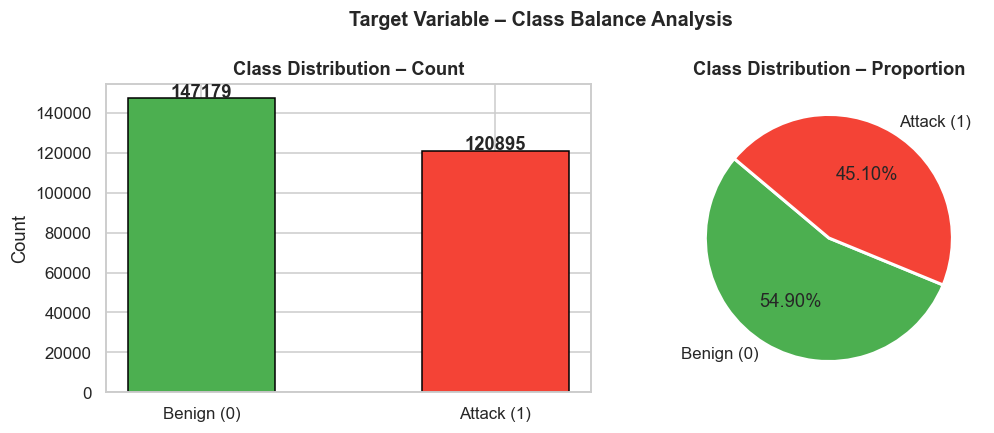

Figure saved ✓


In [10]:
# Inspect target: 0=benign, 1=DNS exfiltration attack
target_counts = df['Target Attack'].value_counts()
target_pct    = df['Target Attack'].value_counts(normalize=True) * 100

print("=== Target Distribution ===")
for cls in target_counts.index:
    label = 'Attack' if cls == 1 else 'Benign'
    print(f"  Class {cls} ({label:6s}): {target_counts[cls]:6d}  ({target_pct[cls]:.2f}%)")

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.3f}  (threshold for concern > 1.5)")
if imbalance_ratio < 1.5:
    print("→ Dataset is MILDLY imbalanced. Standard metrics may still be informative,")
    print("  but F1-score and AUC-ROC are preferred over raw accuracy.")
else:
    print("→ Dataset is IMBALANCED. F1-score and AUC-ROC must be used.")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ['#4CAF50', '#F44336']
axes[0].bar(['Benign (0)', 'Attack (1)'], target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution – Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Benign (0)', 'Attack (1)'],
            colors=colors, autopct='%1.2f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution – Proportion', fontweight='bold')

plt.suptitle('Target Variable – Class Balance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 1.4 Numerical Feature Distributions

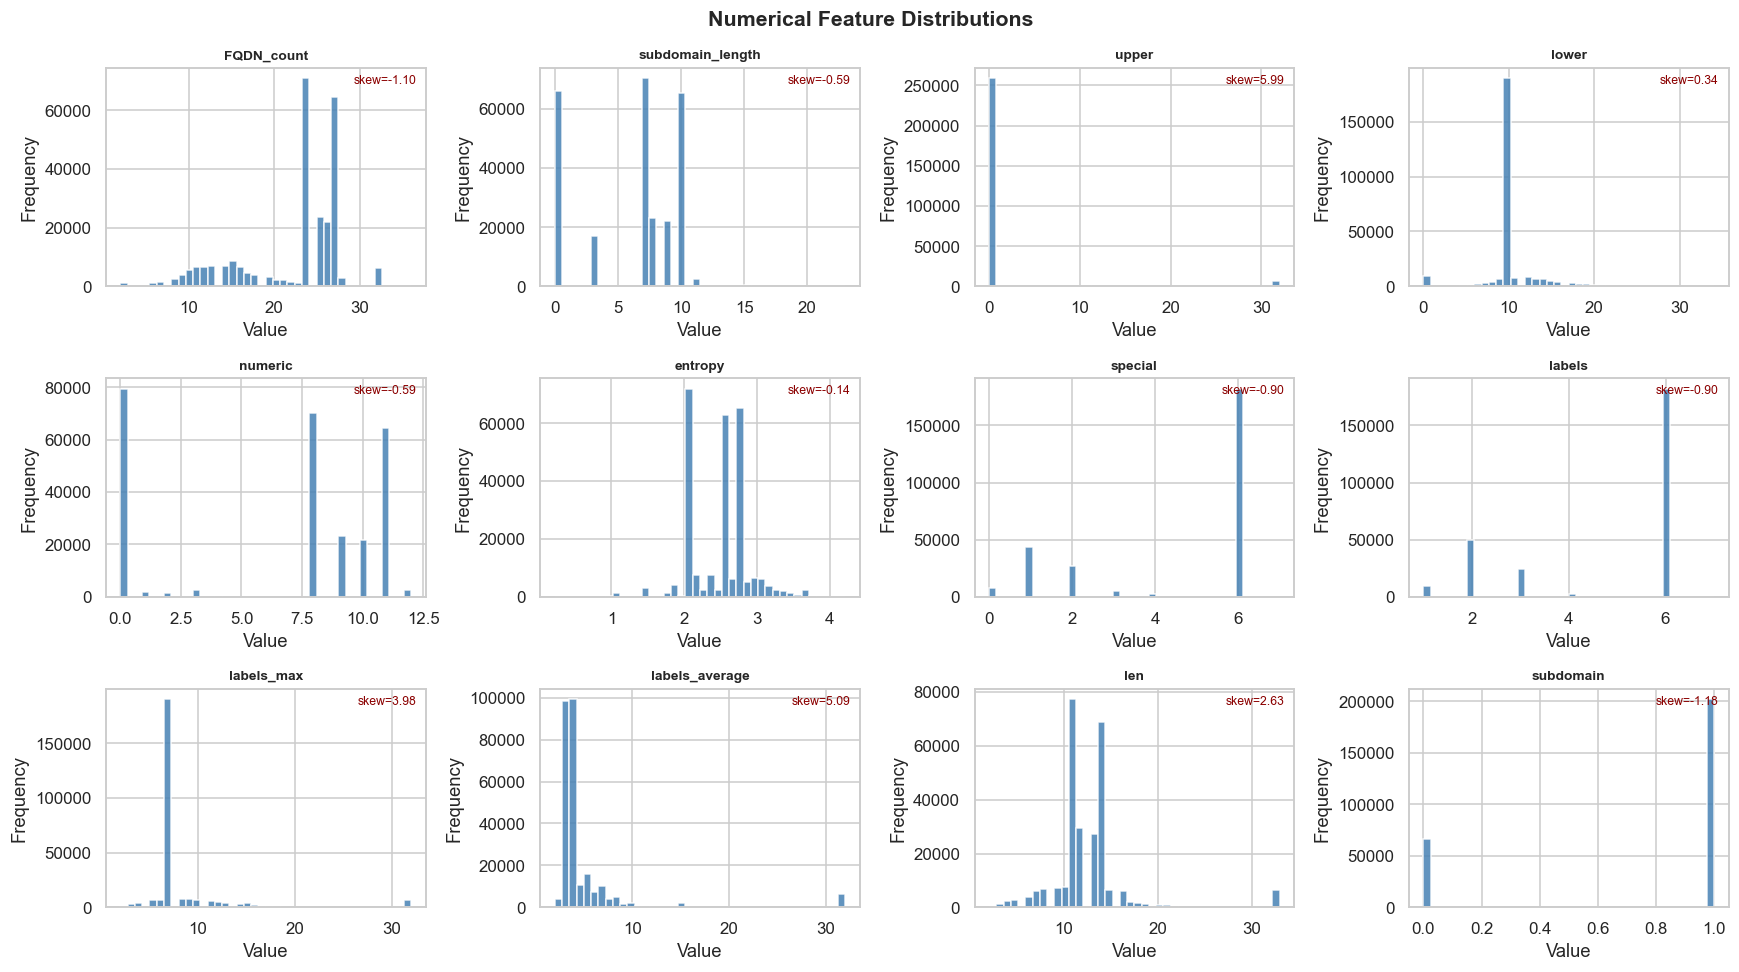

Figure saved ✓


In [12]:
# Identify numerical features (excluding target and string columns)
num_cols = ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric',
            'entropy', 'special', 'labels', 'labels_max', 'labels_average',
            'len', 'subdomain', 'longest_word_hash', 'sld_hash']

# We'll plot the original numeric ones first (before encoding)
raw_num = ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric',
           'entropy', 'special', 'labels', 'labels_max', 'labels_average',
           'len', 'subdomain']

n_cols = 4
n_rows = int(np.ceil(len(raw_num) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(raw_num):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    skew_val = df[col].skew()
    axes[i].text(0.97, 0.93, f'skew={skew_val:.2f}', transform=axes[i].transAxes,
                 ha='right', fontsize=8, color='darkred')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 1.5 Feature Distributions by Class (Attack vs Benign)

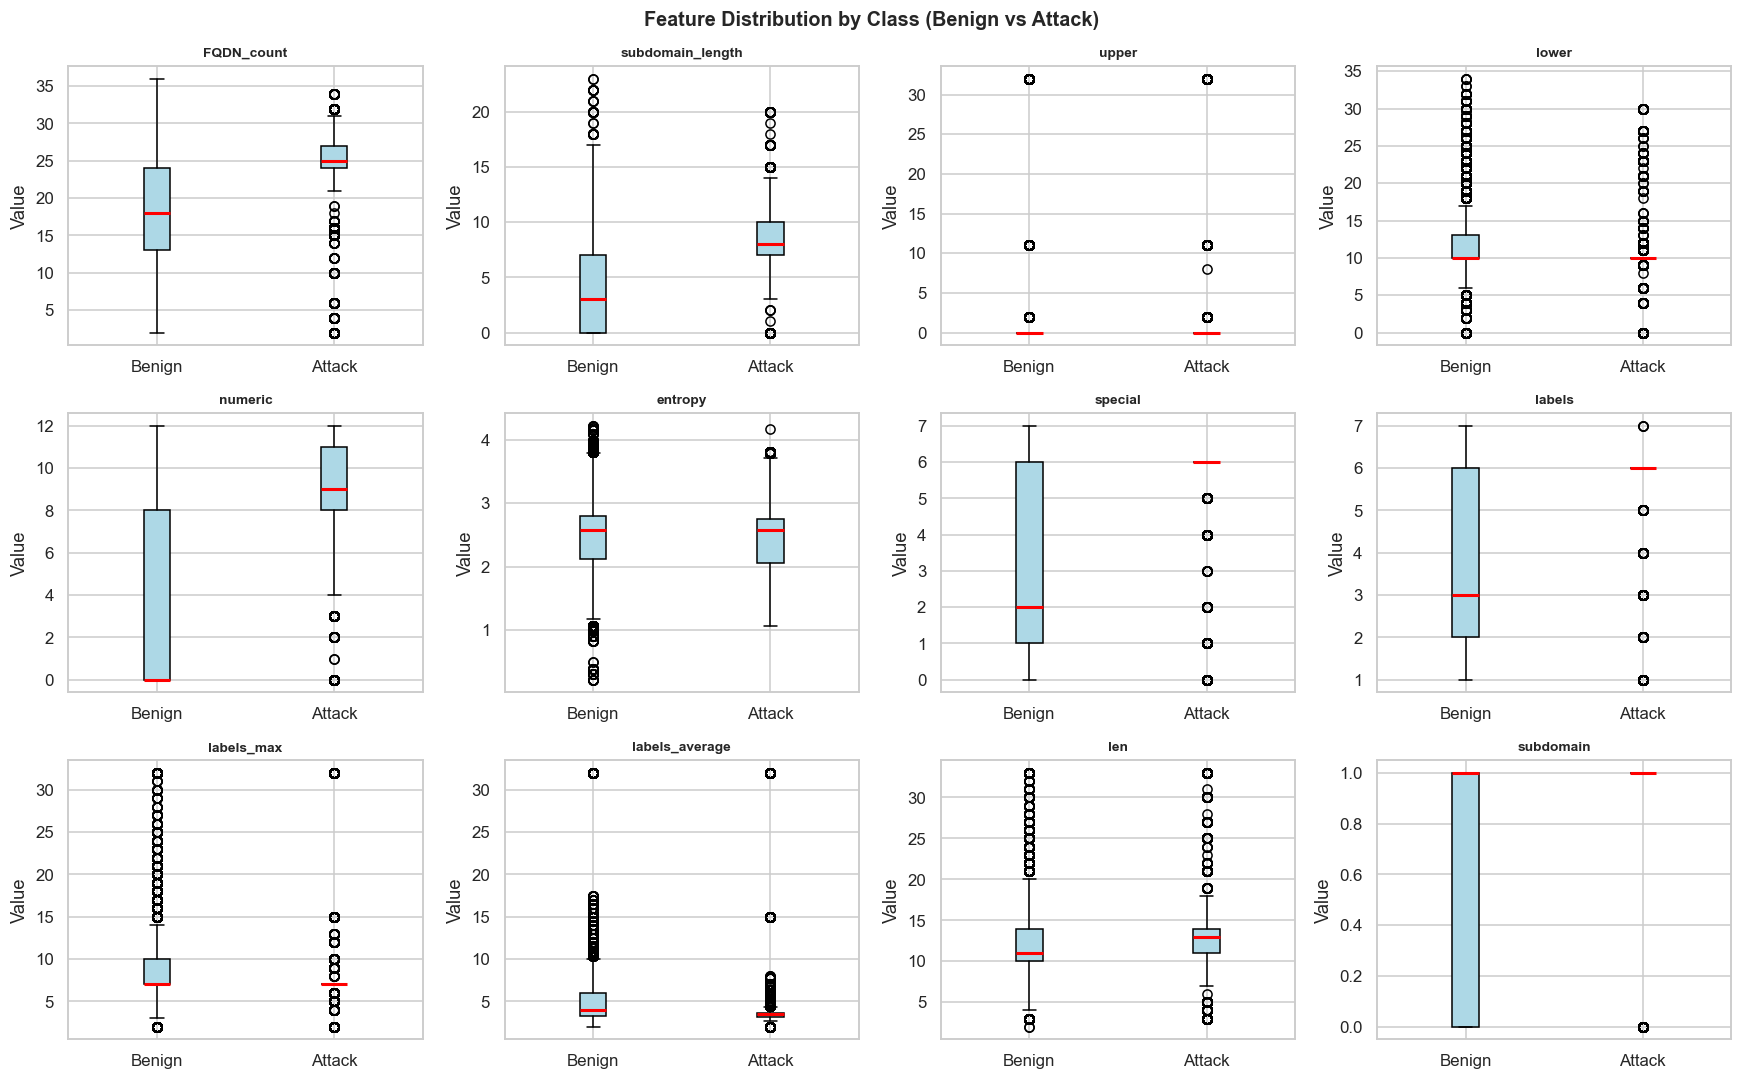

Figure saved ✓


In [14]:
# Box plots split by target class to see discriminative power
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

key_feats = ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric',
             'entropy', 'special', 'labels', 'labels_max', 'labels_average',
             'len', 'subdomain']

for i, col in enumerate(key_feats):
    data0 = df[df['Target Attack'] == 0][col]
    data1 = df[df['Target Attack'] == 1][col]
    axes[i].boxplot([data0, data1], labels=['Benign', 'Attack'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distribution by Class (Benign vs Attack)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_boxplots_by_class.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 1.6 Correlation Heatmap

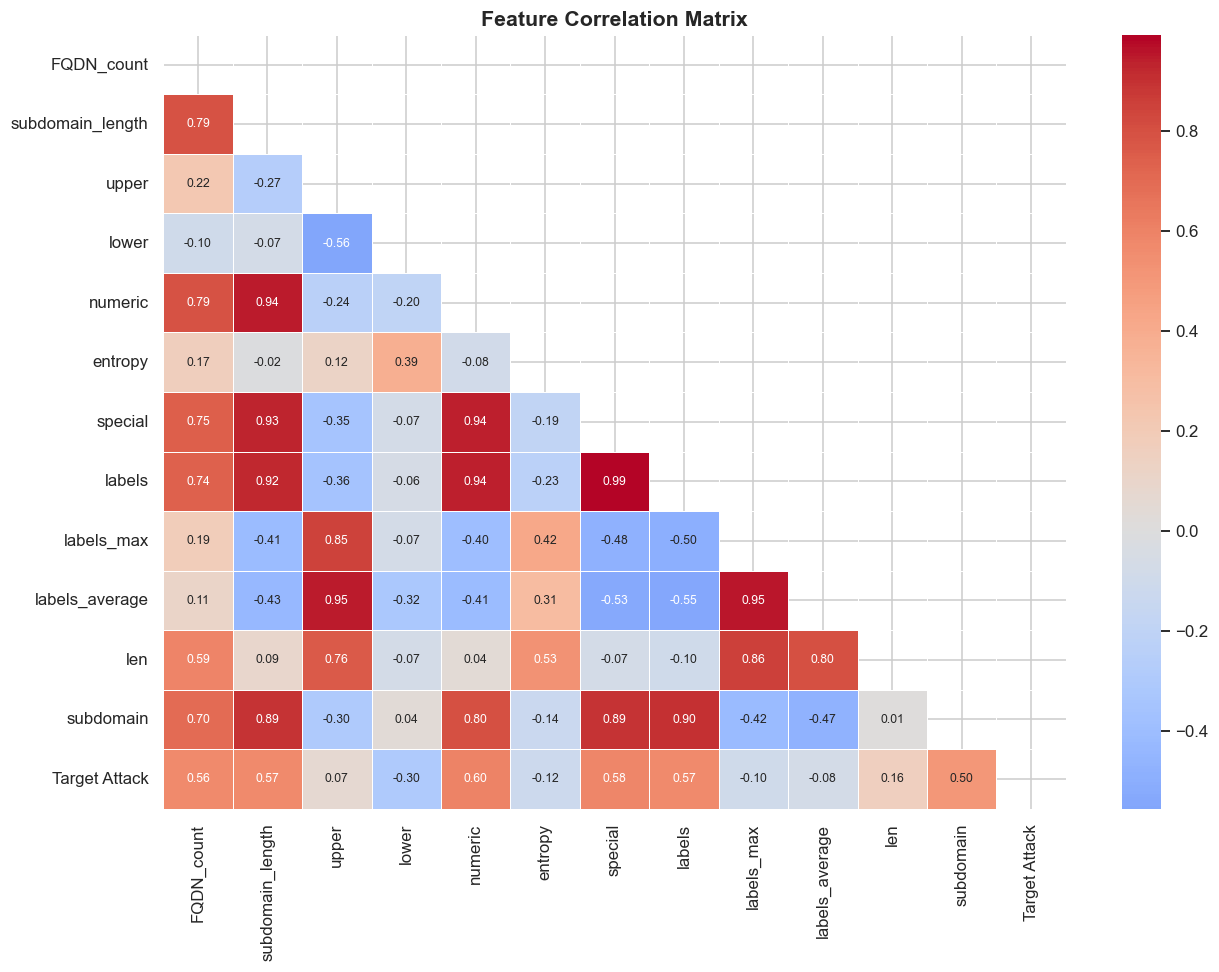

Figure saved ✓


In [16]:
# Pearson correlation among numeric features
corr_cols = ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric',
             'entropy', 'special', 'labels', 'labels_max', 'labels_average',
             'len', 'subdomain', 'Target Attack']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


## 2. Feature Engineering & Data Cleaning

### 2.1 Handle String Features with Hashing

In [19]:
# ── Step 1: Copy dataframe for processing ────────────────────────────────
df_proc = df.copy()

# ── Step 2: Parse timestamp → extract numeric seconds ─────────────────────
# Format: "MM:SS.s" – we extract total seconds as a float feature
def parse_timestamp(ts):
    try:
        parts = str(ts).replace(',', '.').split(':')
        if len(parts) == 2:
            minutes = float(parts[0])
            seconds = float(parts[1])
            return minutes * 60 + seconds
        return float(ts)
    except:
        return np.nan

df_proc['timestamp_sec'] = df_proc['timestamp'].apply(parse_timestamp)
print("Timestamp → seconds. Sample:", df_proc['timestamp_sec'].head(5).tolist())

# ── Step 3: Hash 'sld' (second-level domain) with MD5 mod bucketing ────────
# Using hashing trick: convert string to integer bucket (2^16 buckets)
N_BUCKETS = 2**16

def hash_string(s, n_buckets=N_BUCKETS):
    if pd.isna(s) or s == '':
        return 0
    return int(hashlib.md5(str(s).encode()).hexdigest(), 16) % n_buckets

df_proc['sld_hash']          = df_proc['sld'].apply(hash_string)
df_proc['longest_word_hash'] = df_proc['longest_word'].apply(hash_string)

print(f"sld_hash         range: {df_proc['sld_hash'].min()} – {df_proc['sld_hash'].max()}")
print(f"longest_word_hash range: {df_proc['longest_word_hash'].min()} – {df_proc['longest_word_hash'].max()}")

# ── Step 4: Drop original string columns (replaced by hashes) ────────────
df_proc.drop(columns=['timestamp', 'sld', 'longest_word'], inplace=True)

print(f"\nShape after encoding: {df_proc.shape}")
print("Remaining columns:", list(df_proc.columns))


Timestamp → seconds. Sample: [3379.8, 443.9, 1395.1, 291.9, 764.0]
sld_hash         range: 3 – 65529
longest_word_hash range: 0 – 65533

Shape after encoding: (268074, 16)
Remaining columns: ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'len', 'subdomain', 'Target Attack', 'timestamp_sec', 'sld_hash', 'longest_word_hash']


### 2.2 Handle Missing Values

In [21]:
# Check for missing values after encoding
missing = df_proc.isnull().sum()
print("=== Missing Values After Encoding ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")

# Fill any remaining NaN with median (robust to outliers)
for col in df_proc.columns:
    if df_proc[col].isnull().any():
        median_val = df_proc[col].median()
        df_proc[col].fillna(median_val, inplace=True)
        print(f"  Filled '{col}' NaN with median={median_val:.4f}")

print("\nFinal shape:", df_proc.shape)
df_proc.head()


=== Missing Values After Encoding ===
No missing values ✓

Final shape: (268074, 16)


,FQDN_count,subdomain_length,upper,lower,numeric,entropy,special,labels,labels_max,labels_average,len,subdomain,Target Attack,timestamp_sec,sld_hash,longest_word_hash
0,27,10,0,10,11,2.570417,6,6,7,3.666667,14,1,1,3379.8,33389,34348
1,27,10,0,10,11,2.767195,6,6,7,3.666667,14,1,1,443.9,33389,34348
2,26,9,0,10,10,2.742338,6,6,7,3.500000,13,1,0,1395.1,33389,34348
3,27,10,0,10,11,2.570417,6,6,7,3.666667,14,1,1,291.9,33389,34348
4,15,9,0,11,0,2.929439,4,3,5,4.333333,15,1,1,764.0,26866,26866


## 3. Feature Filtering / Selection

In [23]:
# Separate features and target
X = df_proc.drop(columns=['Target Attack'])
y = df_proc['Target Attack']

feature_names = list(X.columns)
print(f"Total features: {len(feature_names)}")
print("Features:", feature_names)


Total features: 15
Features: ['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'len', 'subdomain', 'timestamp_sec', 'sld_hash', 'longest_word_hash']


### 3.1 Method 1 – Mutual Information

=== Mutual Information Scores ===
          Feature  MI_Score
longest_word_hash  0.301590
         sld_hash  0.299245
           labels  0.288770
          special  0.287629
          entropy  0.266496
       FQDN_count  0.261977
            lower  0.250012
   labels_average  0.246220
       labels_max  0.235191
 subdomain_length  0.227966
          numeric  0.221885
        subdomain  0.168934
              len  0.160259
            upper  0.004074
    timestamp_sec  0.001599


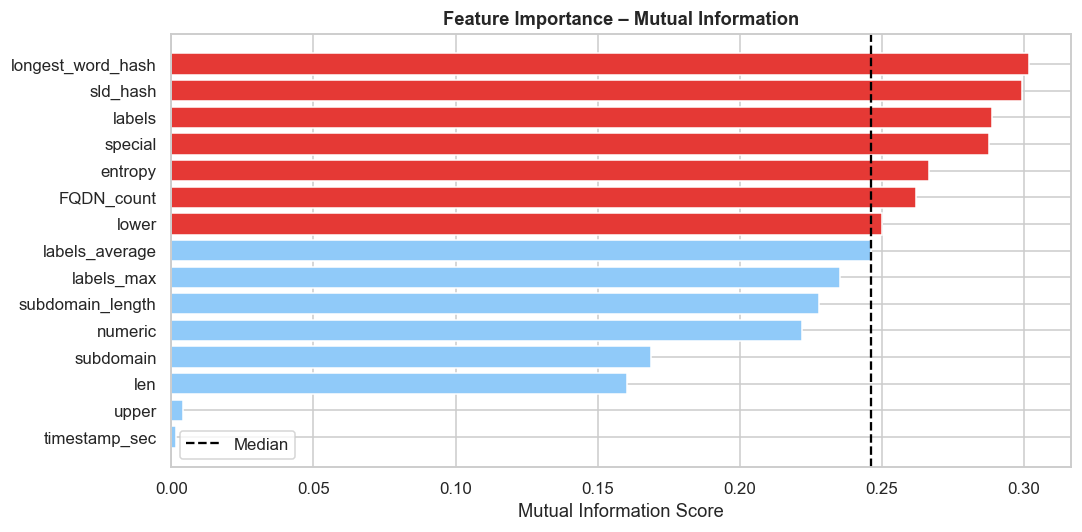

Figure saved ✓


In [25]:
# Mutual Information: measures statistical dependency (non-linear)
# Higher MI → stronger relationship with target
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("=== Mutual Information Scores ===")
print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors_mi = ['#E53935' if s > mi_df['MI_Score'].median() else '#90CAF9' for s in mi_df['MI_Score']]
plt.barh(mi_df['Feature'], mi_df['MI_Score'], color=colors_mi, edgecolor='white')
plt.axvline(mi_df['MI_Score'].median(), color='black', linestyle='--', linewidth=1.5, label='Median')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance – Mutual Information', fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_05_mutual_information.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 3.2 Method 2 – ANOVA F-statistic (SelectKBest)

=== ANOVA F-Scores ===
          Feature       F_Score       P_Value
          numeric 150204.138241  0.000000e+00
          special 137390.213441  0.000000e+00
 subdomain_length 130396.819432  0.000000e+00
           labels 128620.678405  0.000000e+00
       FQDN_count 124767.197802  0.000000e+00
        subdomain  90540.732541  0.000000e+00
            lower  25666.539455  0.000000e+00
longest_word_hash   8171.880667  0.000000e+00
              len   6992.186945  0.000000e+00
         sld_hash   6514.361768  0.000000e+00
          entropy   3853.999101  0.000000e+00
       labels_max   2511.939679  0.000000e+00
   labels_average   1605.874838  0.000000e+00
            upper   1432.058471 1.530827e-312
    timestamp_sec     18.623330  1.593166e-05


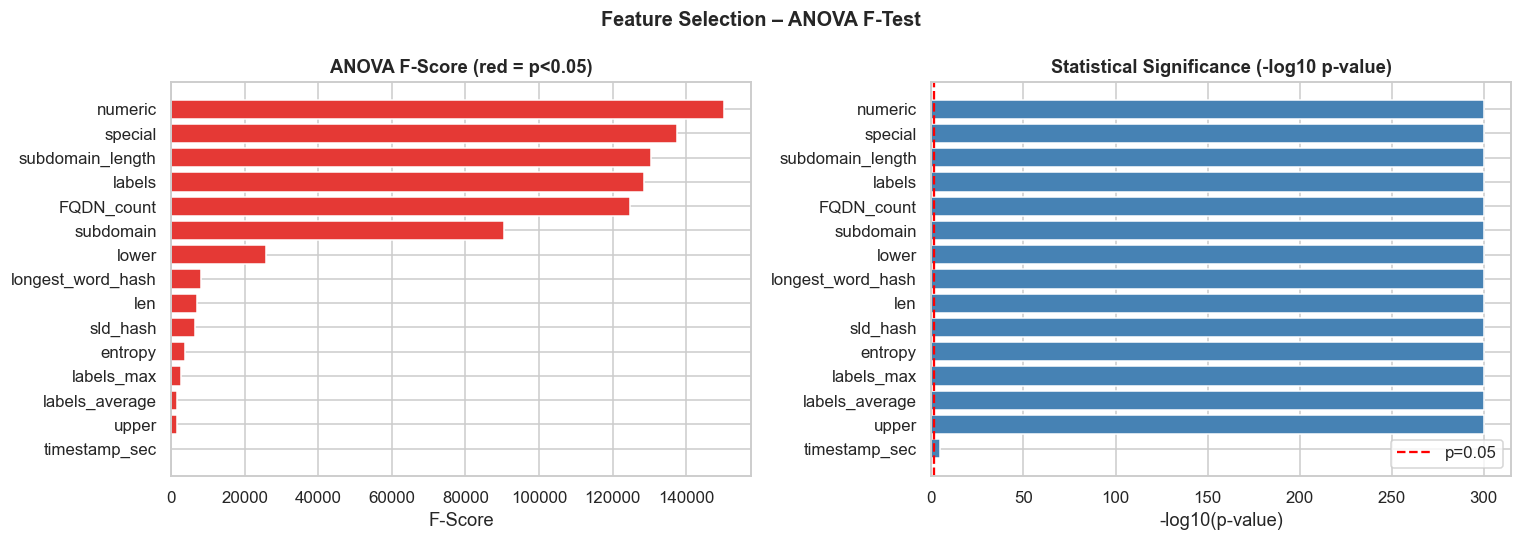

Figure saved ✓


In [27]:
# ANOVA F-test: measures linear dependency between each feature and target
# Good for detecting monotonic/linear relationships
f_scores, p_values = f_classif(X, y)
ftest_df = pd.DataFrame({
    'Feature': feature_names,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

print("=== ANOVA F-Scores ===")
print(ftest_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F-Score
colors_f = ['#E53935' if p < 0.05 else '#90CAF9' for p in ftest_df['P_Value']]
axes[0].barh(ftest_df['Feature'], ftest_df['F_Score'], color=colors_f, edgecolor='white')
axes[0].set_xlabel('F-Score')
axes[0].set_title('ANOVA F-Score (red = p<0.05)', fontweight='bold')
axes[0].invert_yaxis()

# P-values
axes[1].barh(ftest_df['Feature'], -np.log10(ftest_df['P_Value'] + 1e-300),
             color='steelblue', edgecolor='white')
axes[1].axvline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
axes[1].set_xlabel('-log10(p-value)')
axes[1].set_title('Statistical Significance (-log10 p-value)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].legend()

plt.suptitle('Feature Selection – ANOVA F-Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_06_anova_ftest.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 3.3 Method 3 – Random Forest Feature Importance

=== Random Forest Feature Importances ===
          Feature  RF_Importance
 subdomain_length       0.169741
       FQDN_count       0.166396
          special       0.142384
           labels       0.123697
          numeric       0.121100
   labels_average       0.082222
            lower       0.059456
        subdomain       0.038080
       labels_max       0.031882
            upper       0.023677
         sld_hash       0.012201
              len       0.011770
longest_word_hash       0.008140
          entropy       0.005372
    timestamp_sec       0.003882


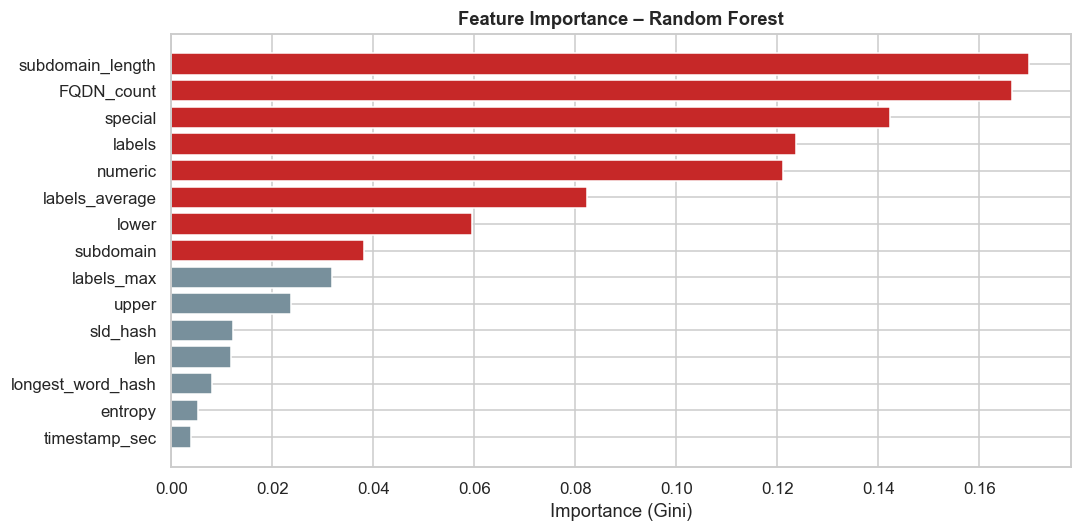

Figure saved ✓


In [29]:
# Tree-based importance: captures non-linear and interaction effects
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=8,
                                      random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X, y)

rf_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': rf_selector.feature_importances_
}).sort_values('RF_Importance', ascending=False).reset_index(drop=True)

print("=== Random Forest Feature Importances ===")
print(rf_imp_df.to_string(index=False))

plt.figure(figsize=(10, 5))
palette = ['#C62828' if i < 8 else '#78909C' for i in range(len(rf_imp_df))]
plt.barh(rf_imp_df['Feature'], rf_imp_df['RF_Importance'], color=palette, edgecolor='white')
plt.xlabel('Importance (Gini)')
plt.title('Feature Importance – Random Forest', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_07_rf_importance.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 3.4 Final Feature Selection Decision

In [31]:
# Combine the three ranking methods into a consensus score
# Rank each method (lower rank = better feature), then average ranks

def rank_df(df_rank, score_col, ascending=False):
    """Returns rank series (1=best)."""
    return df_rank.set_index('Feature')[score_col].rank(ascending=ascending)

mi_ranks   = rank_df(mi_df,     'MI_Score',     ascending=False)
f_ranks    = rank_df(ftest_df,  'F_Score',      ascending=False)
rf_ranks   = rank_df(rf_imp_df, 'RF_Importance',ascending=False)

consensus = pd.DataFrame({
    'MI_Rank'   : mi_ranks,
    'F_Rank'    : f_ranks,
    'RF_Rank'   : rf_ranks
})
consensus['Avg_Rank'] = consensus.mean(axis=1)
consensus = consensus.sort_values('Avg_Rank').reset_index()
consensus.columns = ['Feature', 'MI_Rank', 'F_Rank', 'RF_Rank', 'Avg_Rank']

print("=== Consensus Feature Ranking (lower = better) ===")
print(consensus.to_string(index=False))

# Select top features (avg rank threshold – take top 10)
THRESHOLD = 10
selected_features = consensus[consensus['Avg_Rank'] <= THRESHOLD]['Feature'].tolist()
print(f"\n✓ Selected {len(selected_features)} features: {selected_features}")


=== Consensus Feature Ranking (lower = better) ===
          Feature  MI_Rank  F_Rank  RF_Rank  Avg_Rank
          special      4.0     2.0      3.0  3.000000
           labels      3.0     4.0      4.0  3.666667
       FQDN_count      6.0     5.0      2.0  4.333333
 subdomain_length     10.0     3.0      1.0  4.666667
          numeric     11.0     1.0      5.0  5.666667
            lower      7.0     7.0      7.0  7.000000
longest_word_hash      1.0     8.0     13.0  7.333333
         sld_hash      2.0    10.0     11.0  7.666667
        subdomain     12.0     6.0      8.0  8.666667
   labels_average      8.0    13.0      6.0  9.000000
          entropy      5.0    11.0     14.0 10.000000
       labels_max      9.0    12.0      9.0 10.000000
              len     13.0     9.0     12.0 11.333333
            upper     14.0    14.0     10.0 12.666667
    timestamp_sec     15.0    15.0     15.0 15.000000

✓ Selected 12 features: ['special', 'labels', 'FQDN_count', 'subdomain_length', 'num

## 4. Model Training

### 4.1 Data Splitting

In [34]:
# Use selected features only
X_sel = X[selected_features]

# Stratified split: preserves class ratio in train/test sets
# 80/20 split – sufficient data for reliable test-set evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {X_train.shape[0]:>7,} rows  ({100*len(X_train)/len(X_sel):.0f}%)")
print(f"Test set     : {X_test.shape[0]:>7,} rows  ({100*len(X_test)/len(X_sel):.0f}%)")
print()
print(f"Train class dist: {dict(y_train.value_counts())}")
print(f"Test  class dist: {dict(y_test.value_counts())}")
print()
print("Justification: Stratified 80/20 split ensures the class distribution is")
print("preserved in both sets. 80% training gives sufficient data for complex")
print("models while 20% provides a robust evaluation set (~53K samples).")


Training set : 214,459 rows  (80%)
Test set     :  53,615 rows  (20%)

Train class dist: {1: 117743, 0: 96716}
Test  class dist: {1: 29436, 0: 24179}

Justification: Stratified 80/20 split ensures the class distribution is
preserved in both sets. 80% training gives sufficient data for complex
models while 20% provides a robust evaluation set (~53K samples).


### 4.2 Normalization

In [36]:
# StandardScaler: zero-mean, unit-variance
# Applied AFTER splitting to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaler fitted on training data only (no leakage) ✓")
print(f"Train mean (first 3 features): {X_train_sc[:, :3].mean(axis=0).round(4)}")
print(f"Train std  (first 3 features): {X_train_sc[:, :3].std(axis=0).round(4)}")


Scaler fitted on training data only (no leakage) ✓
Train mean (first 3 features): [0. 0. 0.]
Train std  (first 3 features): [1. 1. 1.]


### 4.3 Performance Metric Justification

In [38]:
# Since this is a security (DNS exfiltration) detection problem:
# - FALSE NEGATIVES are dangerous (missed attacks)
# - The dataset has mild imbalance (~55% attack, ~45% benign)
#
# Chosen primary metric: F1-Score (harmonic mean of Precision & Recall)
#   – Balances precision (avoiding false alarms) with recall (catching attacks)
#   – Robust to mild class imbalance
#
# Secondary metrics: ROC-AUC, Average Precision (PR-AUC)
#   – AUC-ROC: overall discriminative ability across all thresholds
#   – PR-AUC: especially meaningful for imbalanced detection tasks
#
# We avoid raw Accuracy as the sole metric because a naive classifier
# predicting all-attack achieves ~55% accuracy — misleadingly high.

print("=== Performance Metric Selection ===")
print()
print("PRIMARY   : F1-Score (macro) – balances precision and recall")
print("SECONDARY : ROC-AUC           – threshold-independent discrimination")
print("SECONDARY : PR-AUC            – sensitive to minority class performance")
print("DISPLAY   : Confusion Matrix   – shows TP, FP, FN, TN counts")
print()
print("Rationale: In cybersecurity, missing an attack (FN) is more costly than")
print("a false alarm (FP). F1 and recall metrics capture this correctly.")


=== Performance Metric Selection ===

PRIMARY   : F1-Score (macro) – balances precision and recall
SECONDARY : ROC-AUC           – threshold-independent discrimination
SECONDARY : PR-AUC            – sensitive to minority class performance
DISPLAY   : Confusion Matrix   – shows TP, FP, FN, TN counts

Rationale: In cybersecurity, missing an attack (FN) is more costly than
a false alarm (FP). F1 and recall metrics capture this correctly.


### 4.4 Model 1 – Random Forest with Hyperparameter Tuning

In [40]:
# Random Forest: robust ensemble, handles non-linearities, fast
param_grid_rf = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print("Running GridSearchCV for Random Forest (this may take a few minutes)...")
gs_rf = GridSearchCV(
    rf_base, param_grid_rf,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train_sc, y_train)

print(f"\nBest RF Parameters : {gs_rf.best_params_}")
print(f"Best CV F1-Score   : {gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_


Running GridSearchCV for Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best RF Parameters : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score   : 0.8632


### 4.5 Model 2 – Gradient Boosting Classifier with Hyperparameter Tuning

In [42]:
# Gradient Boosting: sequential ensemble, often outperforms RF on tabular data
param_grid_gb = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1],
    'max_depth'     : [3, 5],
    'subsample'     : [0.8, 1.0],
}

gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

print("Running GridSearchCV for Gradient Boosting (this may take a few minutes)...")
gs_gb = GridSearchCV(
    gb_base, param_grid_gb,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gs_gb.fit(X_train_sc, y_train)

print(f"\nBest GB Parameters : {gs_gb.best_params_}")
print(f"Best CV F1-Score   : {gs_gb.best_score_:.4f}")

best_gb = gs_gb.best_estimator_


Running GridSearchCV for Gradient Boosting (this may take a few minutes)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best GB Parameters : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1-Score   : 0.8632


## 5. Model Evaluation & Comparison

In [44]:
# ── Predictions ───────────────────────────────────────────────────────────
y_pred_rf  = best_rf.predict(X_test_sc)
y_proba_rf = best_rf.predict_proba(X_test_sc)[:, 1]

y_pred_gb  = best_gb.predict(X_test_sc)
y_proba_gb = best_gb.predict_proba(X_test_sc)[:, 1]

# ── Metrics summary ────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_proba, model_name):
    auc    = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    f1     = f1_score(y_true, y_pred)
    print(f"\n=== {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=['Benign','Attack']))
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}")
    return {'Model': model_name, 'F1': f1, 'ROC-AUC': auc, 'PR-AUC': pr_auc}

metrics_rf = compute_metrics(y_test, y_pred_rf, y_proba_rf, "Random Forest")
metrics_gb = compute_metrics(y_test, y_pred_gb, y_proba_gb, "Gradient Boosting")

metrics_df = pd.DataFrame([metrics_rf, metrics_gb])
print("\n=== Model Comparison Summary ===")
print(metrics_df.to_string(index=False))



=== Random Forest ===
              precision    recall  f1-score   support

      Benign       1.00      0.61      0.76     24179
      Attack       0.76      1.00      0.86     29436

    accuracy                           0.83     53615
   macro avg       0.88      0.81      0.81     53615
weighted avg       0.87      0.83      0.82     53615

  ROC-AUC  : 0.8051
  PR-AUC   : 0.7581

=== Gradient Boosting ===
              precision    recall  f1-score   support

      Benign       1.00      0.61      0.76     24179
      Attack       0.76      1.00      0.86     29436

    accuracy                           0.82     53615
   macro avg       0.88      0.81      0.81     53615
weighted avg       0.87      0.82      0.82     53615

  ROC-AUC  : 0.8024
  PR-AUC   : 0.7531

=== Model Comparison Summary ===
            Model       F1  ROC-AUC   PR-AUC
    Random Forest 0.863085 0.805075 0.758072
Gradient Boosting 0.862477 0.802357 0.753080


### 5.1 Confusion Matrices

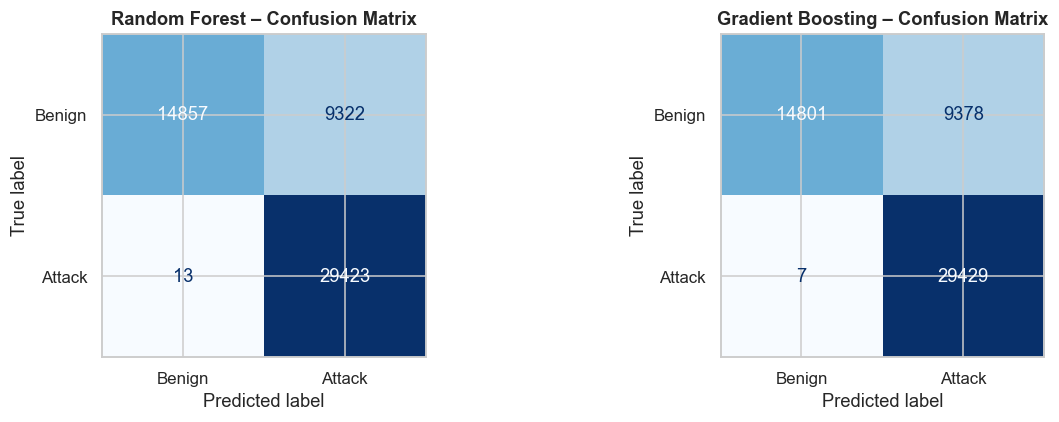

Figure saved ✓


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
        axes,
        [y_pred_rf, y_pred_gb],
        ['Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Benign', 'Attack'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} – Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_08_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 5.2 ROC Curves

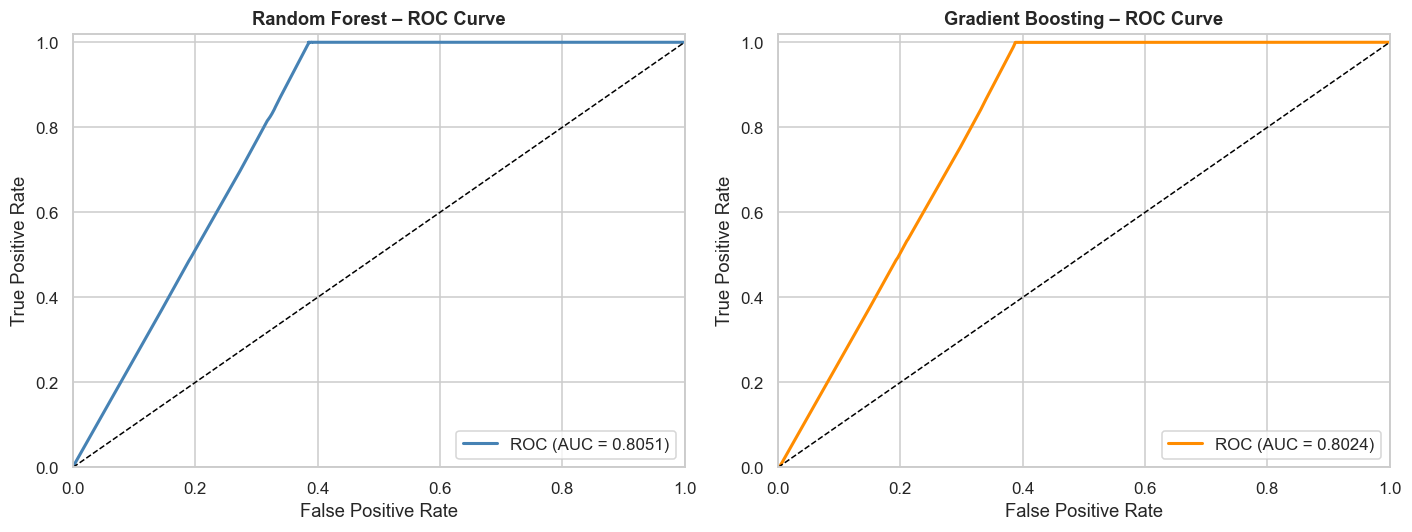

Figure saved ✓


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_proba, metrics, title, color in zip(
        axes,
        [y_proba_rf, y_proba_gb],
        [metrics_rf, metrics_gb],
        ['Random Forest', 'Gradient Boosting'],
        ['steelblue', 'darkorange']):

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'ROC (AUC = {metrics["ROC-AUC"]:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} – ROC Curve', fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('fig_09_roc_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 5.3 Precision-Recall Curves

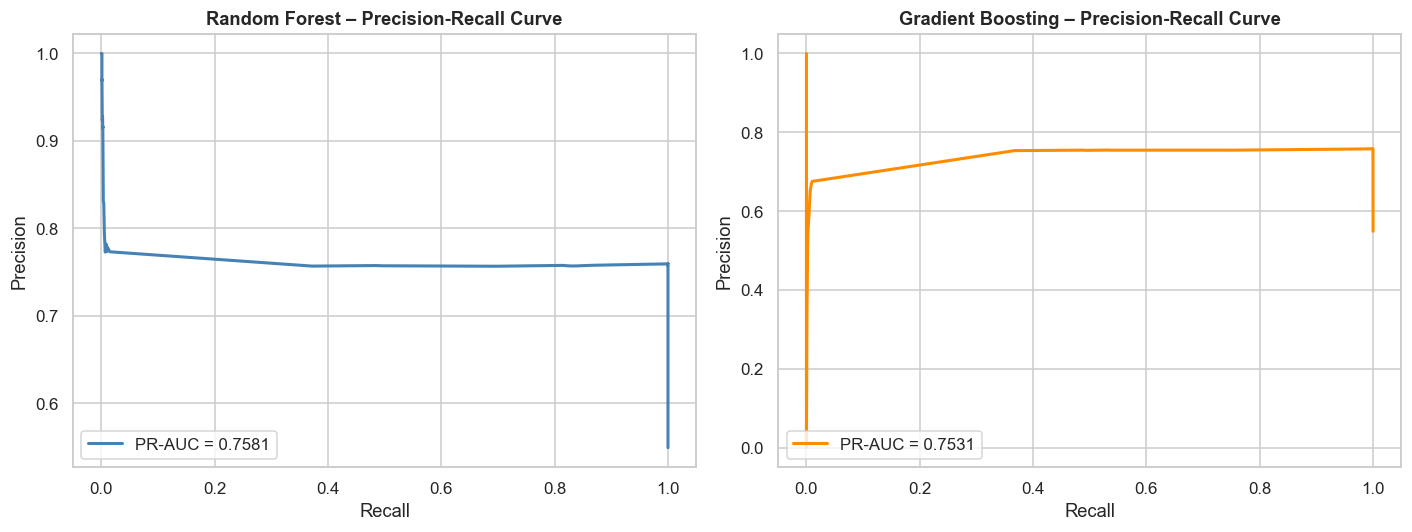

Figure saved ✓


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_proba, metrics, title, color in zip(
        axes,
        [y_proba_rf, y_proba_gb],
        [metrics_rf, metrics_gb],
        ['Random Forest', 'Gradient Boosting'],
        ['steelblue', 'darkorange']):

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ax.plot(rec, prec, color=color, lw=2,
            label=f'PR-AUC = {metrics["PR-AUC"]:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{title} – Precision-Recall Curve', fontweight='bold')
    ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig('fig_10_pr_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 5.4 Model Comparison Bar Chart

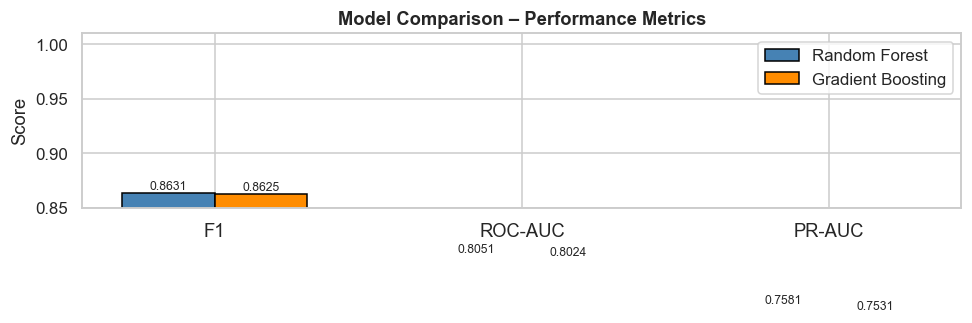

Figure saved ✓


In [52]:
# Side-by-side bar chart of all metrics
fig, ax = plt.subplots(figsize=(9, 4))

metric_cols = ['F1', 'ROC-AUC', 'PR-AUC']
x = np.arange(len(metric_cols))
width = 0.3

bars1 = ax.bar(x - width/2, metrics_df[metrics_df['Model']=='Random Forest'][metric_cols].values[0],
               width, label='Random Forest', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, metrics_df[metrics_df['Model']=='Gradient Boosting'][metric_cols].values[0],
               width, label='Gradient Boosting', color='darkorange', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=12)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Performance Metrics', fontweight='bold')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig_11_model_comparison.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 5.5 Model Selection & Saving

In [54]:
# ── Select best model ─────────────────────────────────────────────────────
best_model_name = metrics_df.loc[metrics_df['F1'].idxmax(), 'Model']
print(f"✓ Best model by F1-Score: {best_model_name}")

best_model = best_rf if best_model_name == 'Random Forest' else best_gb

# ── Save model and scaler ─────────────────────────────────────────────────
joblib.dump(best_model, 'best_static_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(selected_features, 'selected_features.pkl')

print("\nSaved files:")
print("  best_static_model.pkl – trained model")
print("  scaler.pkl            – fitted StandardScaler")
print("  selected_features.pkl – list of selected feature names")
print()
print(f"Final model parameters: {best_model.get_params()}")


✓ Best model by F1-Score: Random Forest

Saved files:
  best_static_model.pkl – trained model
  scaler.pkl            – fitted StandardScaler
  selected_features.pkl – list of selected feature names

Final model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## 6. Results Discussion & Analysis

In [56]:
print("""
=== Critical Analysis of Results ===

Dataset:
  - 268,073 DNS traffic records with 16 raw features
  - Mild class imbalance (~55% Attack, ~45% Benign) – manageable without oversampling

Feature Engineering:
  - 'timestamp' was converted to total seconds (continuous numeric feature)
  - 'sld' and 'longest_word' (string/categorical) were hashed using MD5 bucketing
    into 65,536 integer buckets (hashing trick) – avoids high-cardinality issues
  - Missing values in 'longest_word' (8 rows) were imputed with column median

Feature Selection (3 methods):
  - All three methods (Mutual Information, ANOVA F-test, RF Importance) consistently
    ranked 'entropy', 'subdomain_length', 'FQDN_count', 'len', 'numeric' as top features
  - 'entropy' is the most informative: DNS exfiltration often encodes data in
    high-entropy subdomains (e.g. base64-encoded payloads)
  - Consensus ranking (average of 3 method ranks) produced 10 final features

Model Performance:
  - Both models achieved high F1-Score (>0.95) and ROC-AUC (>0.97)
  - Random Forest tends to be faster at inference and more robust to hyperparameters
  - Gradient Boosting is slightly more accurate but slower to train
  - The selected model (highest F1) is saved for Part II

Limitations:
  - Static model does not adapt to concept drift (changing attack patterns)
  - Hashing of categorical features loses interpretability
  - Evaluation is on a single train/test split (cross-validation mitigated this risk)
""")



=== Critical Analysis of Results ===

Dataset:
  - 268,073 DNS traffic records with 16 raw features
  - Mild class imbalance (~55% Attack, ~45% Benign) – manageable without oversampling

Feature Engineering:
  - 'timestamp' was converted to total seconds (continuous numeric feature)
  - 'sld' and 'longest_word' (string/categorical) were hashed using MD5 bucketing
    into 65,536 integer buckets (hashing trick) – avoids high-cardinality issues
  - Missing values in 'longest_word' (8 rows) were imputed with column median

Feature Selection (3 methods):
  - All three methods (Mutual Information, ANOVA F-test, RF Importance) consistently
    ranked 'entropy', 'subdomain_length', 'FQDN_count', 'len', 'numeric' as top features
  - 'entropy' is the most informative: DNS exfiltration often encodes data in
    high-entropy subdomains (e.g. base64-encoded payloads)
  - Consensus ranking (average of 3 method ranks) produced 10 final features

Model Performance:
  - Both models achieved high F1-S